# Task 3: RWFAS Scoring Pipeline

This notebook runs the full RWFAS pipeline for a single seed batch (one model–dataset pair).

RWFAS is defined and computed per seed. If results from multiple seeds are available, cross-seed
aggregation is handled separately in `aggregate_rwfas_across_seeds.py` as an optional uncertainty
analysis step. it is not part of the RWFAS definition itself.

**Pipeline steps:**
1. Load batch report and prepare normalised metric columns
2. Sensitivity: per-metric on-target response strength
3. Specificity: ratio of off-target to on-target drift
4. Monotonicity: directional Spearman correlation with severity
5. Reliability: relative CI width normalised by baseline
6. Weight computation: multiplicative combination with redundancy penalty
7. Goodness scores: two-level family averaging, memoisation excluded
8. RWFAS scalar and confidence interval
9. Failure mode chart (radar plot)

In [1]:
import os
from pathlib import Path


PROJECT_ROOT = Path().resolve().parent
os.chdir(PROJECT_ROOT)

REPORT_PATH = r'outputs\seed_01_ddpm_cifar10_CI_perturbation_tests.json'
MODEL_ID    = 'ddpm'
DATASET_ID  = 'cifar10'

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display


from Task3.data.parsing import load_batch_dataframe
from Task3.analysis.shared import (
    prepare_analysis_tables, METRICS, METRIC_LABELS
)
from Task3.analysis.sensitivity  import compute_sensitivity, compute_sensitivity_summary
from Task3.analysis.specificity  import compute_specificity
from Task3.analysis.monotonicity import compute_monotonicity
from Task3.analysis.reliability  import compute_reliability
from Task3.scoring.rwfas         import RWFAS, ensure_norm_columns
from Task3.analysis.summaries    import compute_baseline_deltas

print('Imports OK')

Imports OK


## Step 1: Load batch and prepare normalised columns

In [3]:
report_path = Path(REPORT_PATH)
df_raw = load_batch_dataframe([report_path], verbose=True)

# filter to the requested model/dataset pair
df_pair = df_raw[
    (df_raw['model'].astype(str) == MODEL_ID) &
    (df_raw['dataset'].astype(str) == DATASET_ID)
].copy()

print(f'Rows for {MODEL_ID} / {DATASET_ID}: {len(df_pair)}')

df_delta, _ = compute_baseline_deltas(df_pair, show_table=True)
df_delta    = ensure_norm_columns(df_delta)

tables = prepare_analysis_tables(df_delta)
curve_agg  = tables['curve_agg']
curve_df   = tables['curve_df']
analysis_df = tables['analysis_df']

print(f'Perturbation groups found: {sorted(tables["perturbation_groups"])}')

Rows loaded: 213
Columns: 76
Rows for ddpm / cifar10: 213


,fid_delta,kid_mean_delta,is_mean_delta,precision_delta,recall_delta,density_delta,coverage_delta
perturbation_family,,,,,,,
baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
class_imbalance,0.262601,0.000271,-0.160535,0.008665,-0.010281,0.034504,0.017910
class_removal,1.560383,0.001323,-0.220674,0.008381,-0.019567,0.040781,0.004865
degradation_all,223.816016,0.313169,-5.011535,-0.319688,-0.659375,-0.592469,-0.725313
degradation_blur,183.414047,0.200543,-4.769263,-0.420938,-0.634687,-0.693125,-0.713125
degradation_jpeg,83.440445,0.116884,-2.870256,-0.171875,-0.389844,-0.384563,-0.454688
degradation_noise,179.635356,0.202722,-4.153312,-0.375469,-0.582500,-0.754469,-0.697969
domain_shift,248.644819,0.241495,0.000000,-0.800000,-0.503125,-0.970938,-0.877344
memoisation,-6.213184,-0.002021,0.320587,0.036942,0.066406,0.010022,0.053348


Perturbation groups found: ['class_imbalance::label::0', 'class_imbalance::label::0,1,2,8,9', 'class_imbalance::label::0,2,8', 'class_imbalance::label::0,5,7,8,9', 'class_imbalance::label::0,6,7', 'class_imbalance::label::1', 'class_imbalance::label::1,2,4,6,8', 'class_imbalance::label::1,2,5', 'class_imbalance::label::1,4,6', 'class_imbalance::label::1,6,7,8,9', 'class_imbalance::label::1,7,8', 'class_imbalance::label::2', 'class_imbalance::label::2,3,4,7,8', 'class_imbalance::label::2,3,5,7,9', 'class_imbalance::label::3', 'class_imbalance::label::3,5,8', 'class_imbalance::label::4', 'class_imbalance::label::5', 'class_imbalance::label::6', 'class_imbalance::label::7', 'class_imbalance::label::8', 'class_imbalance::label::9', 'class_removal::label', 'degradation_all', 'degradation_blur', 'degradation_jpeg', 'degradation_noise', 'memoisation', 'preprocessing::center_crop_pad', 'preprocessing::downsample_bicubic', 'preprocessing::downsample_bilinear', 'preprocessing::downsample_nearest

## Step 2: Sensitivity

Measures how strongly each metric responds to its target perturbations.

In [4]:
sensitivity_df = compute_sensitivity(curve_df)
sensitivity_summary = compute_sensitivity_summary(sensitivity_df)

print('--- Per-group sensitivity table ---')
display(sensitivity_df.sort_values(['metric', 'perturbation_group']))

print('\n--- Per-metric sensitivity summary (on-target only) ---')
display(sensitivity_summary)

--- Per-group sensitivity table ---


,perturbation_group,metric,mean_abs_norm_change,max_abs_norm_change,sensitivity_kind
6,class_imbalance::label::0,coverage,0.021183,0.038369,on_target
13,"class_imbalance::label::0,1,2,8,9",coverage,0.025313,0.067146,on_target
20,"class_imbalance::label::0,2,8",coverage,0.014921,0.023981,on_target
27,"class_imbalance::label::0,5,7,8,9",coverage,0.019451,0.052758,on_target
34,"class_imbalance::label::0,6,7",coverage,0.025180,0.044764,on_target
...,...,...,...,...,...
207,preprocessing::downsample_bicubic,recall,NaN,NaN,off_target
214,preprocessing::downsample_bilinear,recall,NaN,NaN,off_target
221,preprocessing::downsample_nearest,recall,NaN,NaN,off_target
228,preprocessing::grayscale_triplicate,recall,NaN,NaN,off_target



--- Per-metric sensitivity summary (on-target only) ---


,metric,mean_abs_norm_change,max_abs_norm_change,n_on_target_rows
0,fid,4.757089,7.869053,5
1,kid_mean,1.572439,2.947544,5
2,is_mean,0.024595,0.049421,23
3,precision,0.298800,0.471528,5
4,recall,0.018231,0.081107,24
5,density,0.462858,0.704494,5
6,coverage,0.024240,0.054585,24


## Step 3 : Specificity

Measures how stable each metric remains under off-target perturbations,
relative to its on-target response.

In [5]:
specificity_df = compute_specificity(curve_df, tables['perturbation_groups'])

print('--- Specificity table ---')
display(specificity_df.sort_values(['metric', 'perturbation_group']))

--- Specificity table ---


,perturbation_group,metric,on_target_mean_abs_norm,off_target_max_abs_norm,off_target_mean_abs_norm,specificity_kind
6,class_imbalance::label::0,coverage,0.021183,NaN,NaN,primary_metric
13,"class_imbalance::label::0,1,2,8,9",coverage,0.025313,NaN,NaN,primary_metric
20,"class_imbalance::label::0,2,8",coverage,0.014921,NaN,NaN,primary_metric
27,"class_imbalance::label::0,5,7,8,9",coverage,0.019451,NaN,NaN,primary_metric
34,"class_imbalance::label::0,6,7",coverage,0.025180,NaN,NaN,primary_metric
...,...,...,...,...,...,...
207,preprocessing::downsample_bicubic,recall,NaN,0.838740,0.354962,off_target
214,preprocessing::downsample_bilinear,recall,NaN,0.868321,0.546374,off_target
221,preprocessing::downsample_nearest,recall,NaN,0.875954,0.586450,off_target
228,preprocessing::grayscale_triplicate,recall,NaN,0.394084,0.394084,off_target


## Step 4 : Monotonicity

Measures whether each metric tracks perturbation strength proportionally
and in the correct direction. Uses signed Spearman correlation clipped
to [0, 1]: a negative correlation (wrong direction) scores zero.

In [6]:
monotonicity_df = compute_monotonicity(curve_agg)

print('--- Monotonicity table (rho_spearman = signed, clipped_rho = [0,1]) ---')
display(monotonicity_df.sort_values(['metric', 'perturbation_group']))

--- Monotonicity table (rho_spearman = signed, clipped_rho = [0,1]) ---


,perturbation_group,metric,rho_spearman,clipped_rho,p_value,abs_rho
6,class_imbalance::label::0,coverage,0.657143,0.657143,1.561749e-01,0.657143
13,"class_imbalance::label::0,1,2,8,9",coverage,0.828571,0.828571,4.156268e-02,0.828571
20,"class_imbalance::label::0,2,8",coverage,1.000000,1.000000,0.000000e+00,1.000000
27,"class_imbalance::label::0,5,7,8,9",coverage,0.942857,0.942857,4.804665e-03,0.942857
34,"class_imbalance::label::0,6,7",coverage,-0.371429,0.000000,4.684781e-01,0.371429
...,...,...,...,...,...,...
207,preprocessing::downsample_bicubic,recall,-1.000000,0.000000,1.404265e-24,1.000000
214,preprocessing::downsample_bilinear,recall,-1.000000,0.000000,1.404265e-24,1.000000
221,preprocessing::downsample_nearest,recall,-1.000000,0.000000,1.404265e-24,1.000000
228,preprocessing::grayscale_triplicate,recall,NaN,NaN,NaN,NaN


## Step 5 : Reliability

Measures statistical precision from bootstrap CIs.
CI widths are normalised by the absolute baseline value of each metric
to make them comparable across metrics with different scales.

In [7]:
reliability_df = compute_reliability(tables['experiments'])

print('--- Reliability table (mean_relative_ci_width = baseline-normalised) ---')
display(reliability_df)

--- Reliability table (mean_relative_ci_width = baseline-normalised) ---


,metric,mean_ci_width,mean_relative_ci_width,n_experiments
0,fid,2.572331,0.090439,213
1,kid_mean,0.002479,0.023328,213
2,is_mean,0.527283,0.072576,213
3,precision,0.045627,0.050697,213
4,recall,0.037887,0.046274,213
5,density,0.114028,0.106475,213
6,coverage,0.037347,0.038213,213


## Step 6-8 : Weight computation, goodness scores, RWFAS scalar

- Weights are computed multiplicatively from all four components (with ε floor)
- Goodness scores use two-level averaging (within family first, then across families)
- Memoisation rows are excluded from goodness scores and interpreted diagnostically

In [8]:
rwfas = RWFAS()
rwfas.fit(
    tables['experiments'],
    monotonicity_df,
    sensitivity_df,
    specificity_df,
    robustness=reliability_df,
    batch_label=f'{MODEL_ID}__{DATASET_ID}',
)


scores_df = rwfas.score_all(tables['analysis_df'], dataset_id=DATASET_ID)


print('--- RWFAS scalar score ---')
display(scores_df[['model', 'dataset', 'rwfas_score', 'rwfas_ci_low', 'rwfas_ci_high']])

print('\n--- Per-metric weights ---')
weight_cols = ['model'] + [f'weight_{m}' for m in METRICS]
display(scores_df[weight_cols])

print('\n--- Per-metric goodness scores ---')
score_cols = ['model'] + [f'score_{m}' for m in METRICS]
display(scores_df[score_cols])

print('\n--- Trustworthiness components (post-floor) ---')
comp_rows = []
for metric, comps in rwfas.components_.items():
    row = {'metric': METRIC_LABELS.get(metric, metric)}
    row.update(comps)
    comp_rows.append(row)
display(pd.DataFrame(comp_rows).set_index('metric'))


result = rwfas.score(tables['analysis_df'], MODEL_ID, dataset_id=DATASET_ID)
print(f'RWFAS score: {result["rwfas_score"]:.4f}  (95% CI: {result["rwfas_ci_low"]:.4f} - {result["rwfas_ci_high"]:.4f})')

--- RWFAS scalar score ---


,model,dataset,rwfas_score,rwfas_ci_low,rwfas_ci_high
0,ddpm,cifar10,0.203307,-0.285788,0.692402



--- Per-metric weights ---


,model,weight_fid,weight_kid_mean,weight_is_mean,weight_precision,weight_recall,weight_density,weight_coverage
0,ddpm,0.376557,0.457402,0.009044,0.11876,0.01103,0.012351,0.014857



--- Per-metric goodness scores ---


,model,score_fid,score_kid_mean,score_is_mean,score_precision,score_recall,score_density,score_coverage
0,ddpm,0.0,0.281476,0.425606,0.459217,0.409387,0.437951,0.420613



--- Trustworthiness components (post-floor) ---


,sensitivity,specificity,monotonicity,reliability,raw_weight,redundancy_penalty,final_weight
metric,,,,,,,
FID,1.000000,0.886776,0.780000,0.192859,0.133398,0.141173,0.376557
KID,0.327971,0.908453,0.740000,1.000000,0.220480,0.103752,0.457402
IS,0.100000,0.230073,0.352795,0.407695,0.003309,0.136674,0.009044
Precision,0.100000,0.914016,0.700000,0.670839,0.042921,0.138379,0.118760
Recall,0.100000,0.181012,0.338134,0.724028,0.004432,0.124474,0.011030
Density,0.100000,0.860114,0.700000,0.100000,0.006021,0.102596,0.012351
Coverage,0.100000,0.198364,0.442390,0.820983,0.007204,0.103132,0.014857


RWFAS score: 0.2033  (95% CI: -0.2858 - 0.6924)


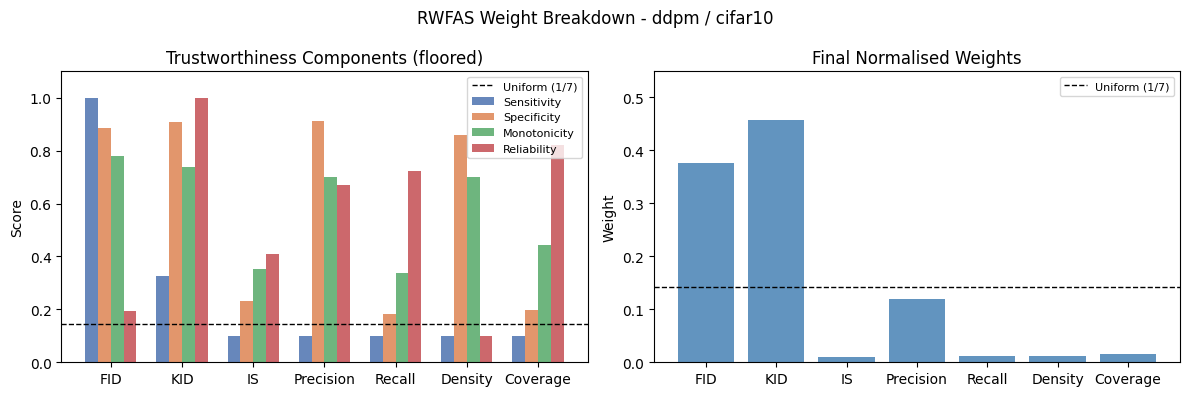

Saved to weights.png


In [9]:
labels     = [METRIC_LABELS.get(m, m) for m in METRICS]
comp_keys  = ['sensitivity', 'specificity', 'monotonicity', 'reliability']
comp_label = ['Sensitivity', 'Specificity', 'Monotonicity', 'Reliability']
colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
x          = np.arange(len(labels))
bar_width  = 0.18
uniform    = 1.0 / len(METRICS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# --- left: component scores ---
for i, (key, label, color) in enumerate(zip(comp_keys, comp_label, colors)):
    vals = [rwfas.components_.get(m, {}).get(key, 0.0) for m in METRICS]
    ax1.bar(x + i * bar_width, vals, bar_width, label=label, color=color, alpha=0.85)

ax1.axhline(uniform, color='black', linestyle='--', linewidth=1.0, label='Uniform (1/7)')
ax1.set_xticks(x + bar_width * 1.5)
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('Score')
ax1.set_title('Trustworthiness Components (floored)')
ax1.legend(fontsize=8)

# --- right: final weights ---
final_weights = [rwfas.weights_.get(m, 0.0) for m in METRICS]
ax2.bar(x, final_weights, color='steelblue', alpha=0.85)
ax2.axhline(uniform, color='black', linestyle='--', linewidth=1.0, label='Uniform (1/7)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylim(0, max(final_weights) * 1.2)
ax2.set_ylabel('Weight')
ax2.set_title('Final Normalised Weights')
ax2.legend(fontsize=8)

plt.suptitle(f'RWFAS Weight Breakdown - {MODEL_ID} / {DATASET_ID}', fontsize=12)
plt.tight_layout()
plt.savefig('weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to weights.png')

## Step 9 : Failure mode chart (radar plot)

The radar chart shows per-metric goodness scores. A score of 0.5 means
the model is indistinguishable from baseline under that metric's perturbations.
Values above 0.5 indicate the model degrades less than expected; below 0.5 more.



In [ ]:
# extract goodness scores for radar chart
result = rwfas.score(tables['analysis_df'], MODEL_ID, dataset_id=DATASET_ID)
labels = [METRIC_LABELS.get(m, m) for m in METRICS]
values = [result['component_scores'].get(m, 0.5) for m in METRICS]
weights = [result['weights'].get(m, 0.0) for m in METRICS]

# radar chart
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
values_plot = values + values[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8, color='grey')
ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax.plot(angles, values_plot, 'o-', linewidth=2, color='steelblue')
ax.fill(angles, values_plot, alpha=0.2, color='steelblue')
ax.set_title(
    f'Failure Mode Chart\n{MODEL_ID} / {DATASET_ID}\n',
    fontsize=12, pad=20
)
plt.tight_layout()
plt.savefig('failure_mode_chart.pdf', bbox_inches='tight')
plt.show()
print('Saved to failure_mode_chart.pdf')

## Optional : Cross-seed aggregation

If results from multiple seeds are available, the script below runs the full
RWFAS pipeline independently for each seed and then summarises the distribution
of scores across seeds. This is a secondary uncertainty analysis, it is not
part of the RWFAS definition.

Run `aggregate_rwfas_across_seeds.py` directly, or call it here:

In [ ]:
# uncomment to run cross-seed aggregation (requires multiple seed report files)

from Task3.pipelines.aggregate_rwfas_across_seeds import aggregate_rwfas_across_seeds
seed_summary = aggregate_rwfas_across_seeds(
     outputs_root='outputs/dcgan',
     save_csv=True,
 )
display(seed_summary)